# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [84]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [85]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [86]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [87]:
numbers = list(range(10))  # список для shuffle

# TODO: двічі ДО set_seed() -- наприклад random.randint(1, 100) і random.shuffle(numbers)
print("--- двічі ДО set_seed() ---")

print("Спроба 1:")
print("randint:", random.randint(1, 100))
nums_copy1 = numbers.copy()
random.shuffle(nums_copy1)
print("shuffle:", nums_copy1)

print("Спроба 2:")
print("randint:", random.randint(1, 100))
nums_copy2 = numbers.copy()
random.shuffle(nums_copy2)
print("shuffle:", nums_copy2)

set_seed()
print("Seed зафіксовано:", SEED)

# TODO: тепер двічі ПІСЛЯ set_seed() -- виклич set_seed() перед КОЖНИМ окремим генеруванням
print("\n--- двічі ПІСЛЯ set_seed() ---")

set_seed()
print("Спроба 1:")
print("randint:", random.randint(1, 100))
nums_copy3 = numbers.copy()
random.shuffle(nums_copy3)
print("shuffle:", nums_copy3)

set_seed()
print("Спроба 2:")
print("randint:", random.randint(1, 100))
nums_copy4 = numbers.copy()
random.shuffle(nums_copy4)
print("shuffle:", nums_copy4)

# TODO: тепер ще двічі без проміжних викликів set_seed()
print("\n--- двічі без проміжних викликів set_seed() ---")

print("Спроба 1:")
print("randint:", random.randint(1, 100))
nums_copy5 = numbers.copy()
random.shuffle(nums_copy5)
print("shuffle:", nums_copy5)

print("Спроба 2:")
print("randint:", random.randint(1, 100))
nums_copy6 = numbers.copy()
random.shuffle(nums_copy6)
print("shuffle:", nums_copy6)


--- двічі ДО set_seed() ---
Спроба 1:
randint: 4
shuffle: [7, 6, 2, 9, 0, 5, 1, 8, 3, 4]
Спроба 2:
randint: 5
shuffle: [6, 7, 2, 9, 5, 4, 8, 3, 1, 0]
Seed зафіксовано: 42

--- двічі ПІСЛЯ set_seed() ---
Спроба 1:
randint: 82
shuffle: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Спроба 2:
randint: 82
shuffle: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]

--- двічі без проміжних викликів set_seed() ---
Спроба 1:
randint: 76
shuffle: [4, 3, 2, 9, 5, 1, 7, 8, 0, 6]
Спроба 2:
randint: 92
shuffle: [5, 1, 9, 0, 2, 4, 7, 3, 6, 8]


### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [88]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [89]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [90]:
# TODO: zeros_arr = np.zeros((3, 4))
zeros_arr = np.zeros((3, 4))

# TODO: sevens_arr = np.full((3, 4), 7)
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [91]:
# TODO: arange_arr = np.arange(0, 20, 2)
arange_arr = np.arange(0, 20, 2)

# TODO: linspace_arr = np.linspace(0, 1, 5)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [92]:
# TODO: identity = np.eye(4)
identity = np.eye(4)
# TODO: random_ints = np.random.randint(0, 10, size=(3, 3))
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)

print(identity.ndim)
print(random_ints.ndim)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[6 3 7]
 [4 6 9]
 [2 6 7]]
2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [93]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std
mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [94]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)
matrix = arr.reshape(3,4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [95]:
df = pd.DataFrame({
    "name": ["Артем", "Вікторія", "Денис", "Надія", "Станіслав"],
    "score": [80, 100, 80, 100, 95]
}) # додай тут дані для DataFrame

# TODO: відфільтрувати score > 80 і відсортувати за score за спаданням
top = df[df["score"] > 80].sort_values("score", ascending=False)
print(top)


        name  score
1   Вікторія    100
3      Надія    100
4  Станіслав     95


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [96]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"
def get_grade(score):
  if score >= 90: return "A"
  elif score >= 75: return "B"
  else: return "C"

df["grade"] = df["score"].apply(get_grade)
print(df)


        name  score grade
0      Артем     80     B
1   Вікторія    100     A
2      Денис     80     B
3      Надія    100     A
4  Станіслав     95     A


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [97]:
# TODO: zeros_t = torch.zeros((2, 3))
# TODO: sevens_t = torch.full((2, 3), 7)
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t)
print(sevens_t)

print(zeros_t.shape, zeros_t.dtype)
print(sevens_t.shape, sevens_t.dtype)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[7, 7, 7],
        [7, 7, 7]])
torch.Size([2, 3]) torch.float32
torch.Size([2, 3]) torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [98]:
# TODO: arange_t = torch.arange(0, 20, 2)
# TODO: linspace_t = torch.linspace(0, 1, 5)
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [99]:
# TODO: from_list = torch.tensor([[1, 2], [3, 4]])
# TODO: random_t = torch.rand(3, 3)
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list)
print(random_t)

print(from_list.shape, from_list.dtype, from_list.ndim)
print(random_t.shape, random_t.dtype, random_t.ndim)


tensor([[1, 2],
        [3, 4]])
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
torch.Size([2, 2]) torch.int64 2
torch.Size([3, 3]) torch.float32 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [100]:
n = 5.0

# TODO: x = torch.tensor(n, requires_grad=True), y = x ** 2, y.backward()
x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

# надрукувати x.grad.item() і порівняти з 2 * n
print("Автоматичний градієнт:", x.grad.item())
print("Аналітичний градієнт (2*n):", 2 * n)


Автоматичний градієнт: 10.0
Аналітичний градієнт (2*n): 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [101]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

# TODO: цикл градієнтного спуску (20 кроків):
#   loss = (x - 3) ** 2 + 5
#   loss.backward()
#   під torch.no_grad(): x -= lr * x.grad
#   x.grad.zero_()
for step in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()

    with torch.no_grad():
        x -= lr * x.grad

    x.grad.zero_()


print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

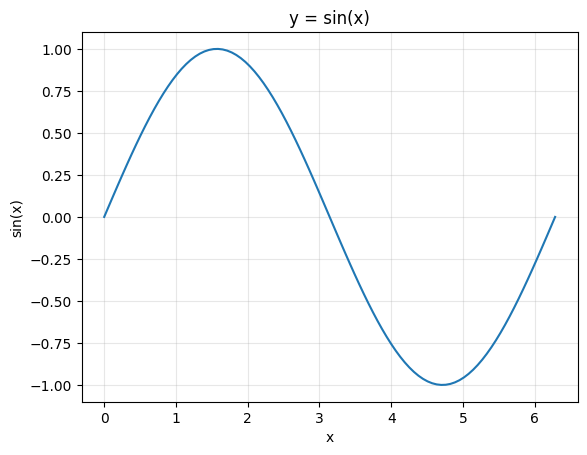

In [102]:
# TODO: xs = np.linspace(0, 2*np.pi, 100), plt.plot(xs, np.sin(xs)), plt.show()
xs = np.linspace(0, 2*np.pi, 100)

plt.plot(xs, np.sin(xs))
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("y = sin(x)")
plt.grid(alpha=0.3)
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

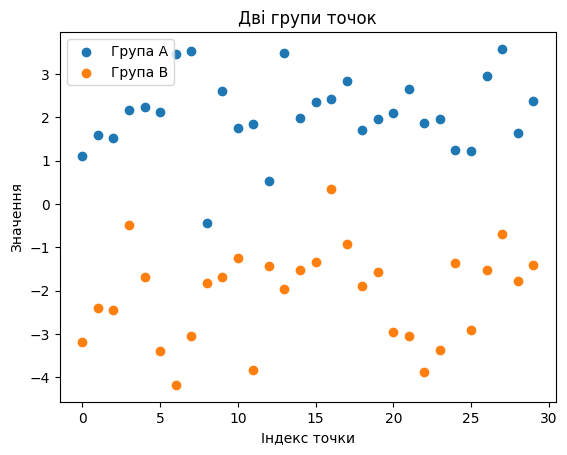

In [103]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
plt.scatter(range(len(group_a)), group_a, color="C0", label="Група A")
plt.scatter(range(len(group_b)), group_b, color="C1", label="Група B")
plt.xlabel("Індекс точки")
plt.ylabel("Значення")
plt.title("Дві групи точок")

# додати plt.legend(), plt.show()
plt.legend()
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [104]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

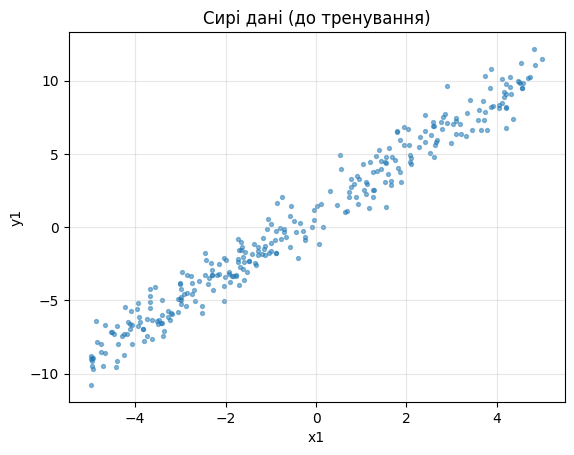

In [105]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
plt.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.5)
plt.xlabel("x1")
plt.ylabel("y1")

# "Сирі дані (до тренування)"
plt.title("Сирі дані (до тренування)")
plt.grid(alpha=0.3)
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [106]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
# train/val/test у пропорції 70/15/15
# x_train1, y_train1 = ...
# x_val1, y_val1 = ...
# x_test1, y_test1 = ...
perm = torch.randperm(TASK1_N)

n_train = int(0.7 * TASK1_N)
n_val = int(0.15 * TASK1_N)

train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]

x_train1, y_train1 = x1[train_idx], y1[train_idx]
x_val1, y_val1 = x1[val_idx], y1[val_idx]
x_test1, y_test1 = x1[test_idx], y1[test_idx]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [107]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


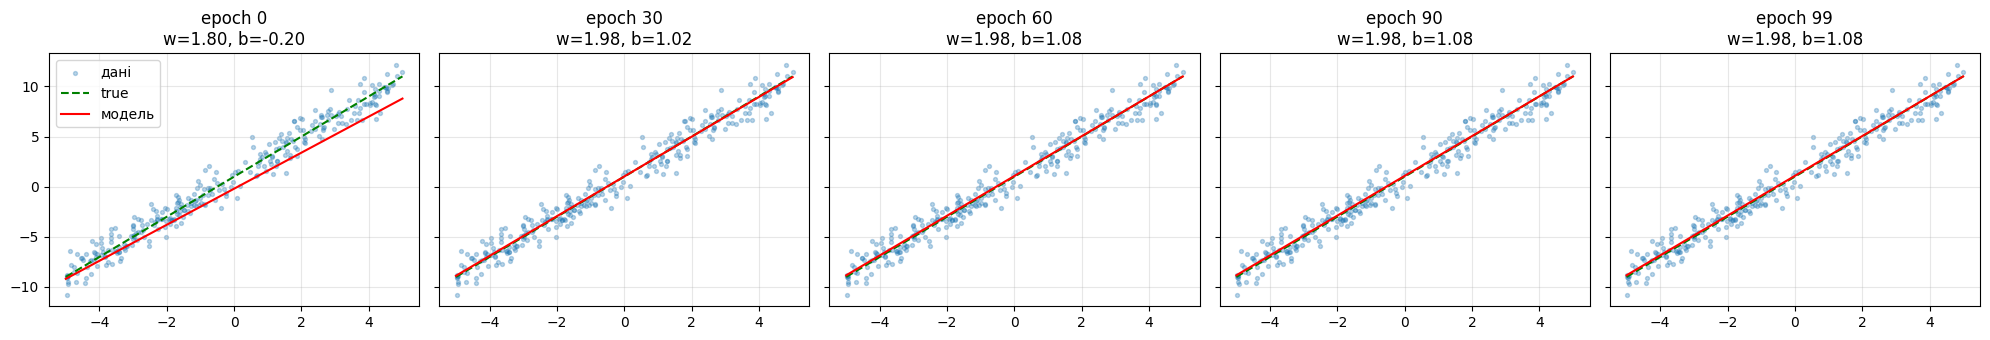

In [108]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

**Власний сценарій: кількість пар на тиждень → вільний час**

**Сценарій**. Досліджуємо залежність між кількістю пар у студента за тиждень і кількістю годин вільного часу, який залишається на тиждень.
Логічно припустити, що чим більше пар відвідує студент, тим менше вільного часу в нього залишається — не лише через саму присутність на парах, а й через час на підготовку до них, дорогу до університету тощо.

**Модель залежності:**
$$\text{вільний_час} = w \cdot \text{кількість_пар} + b + \varepsilon$$

**Обрані параметри:**
- $w = -1.5$ — кожна додаткова пара на тиждень "забирає" в середньому 1.5 години вільного часу. Це число враховує не тільки саму пару (зазвичай ~1.2 год), а й непрямі витрати часу навколо не (підготовка, дорога), тому коефіцієнт трохи вищий за "голу" тривалість однієї пари.
- b=40 — базовий рівень вільного часу на тиждень при нульовій кількості пар. Тиждень має 168 годин; віднявши приблизний час на сон (56 год), побут, харчування та інші фіксовані справи (70 год), залишається орієнтовно 40 годин "гнучкого" часу, який студент міг би витратити на навчання чи відпочинок.
- Діапазон $x$ (кількість пар на тиждень): від 0 до 30 — реалістичний діапазон для студентського навантаження.
- Шум $\varepsilon \sim \mathcal{N}(0, 3)$ — стандартне відхилення 3 години відображає те, що реальний вільний час залежить не лише від кількості пар, а й від інших факторів (робота, хобі, індивідуальний темп виконання завдань), які модель напряму не враховує.


In [109]:
TASK2_TRUE_W = -1.5
TASK2_TRUE_B = 40.0
TASK2_N = 300

set_seed()

x2 = torch.empty(TASK2_N, 1).uniform_(0, 30)  # кількість пар на тиждень
noise2 = 3.0 * torch.randn(TASK2_N, 1)  # шум
y2 = TASK2_TRUE_W * x2 + TASK2_TRUE_B + noise2  # вільний час (год)

# зберігаємо у CSV
df2 = pd.DataFrame({
    "pairs_per_week": x2.squeeze().numpy(),
    "free_time_hours": y2.squeeze().numpy()
})
csv_path = os.path.join(ARTIFACT_DIR, "dataset.csv")
df2.to_csv(csv_path, index=False)
print("Дані збережено в:", csv_path)
print(df2.head())

Дані збережено в: /content/drive/MyDrive/ai_systems/lab1/dataset.csv
   pairs_per_week  free_time_hours
0       26.468079        -1.373683
1       27.450119        -4.080220
2       11.485912        25.384970
3       28.779169        -3.455677
4       11.713447        23.641239


In [110]:
def split_data(x, y, n_total, train_frac=0.7, val_frac=0.15, seed=None):
    """Перемішує та розбиває дані на train/val/test."""
    if seed is not None:
        set_seed(seed)
    perm = torch.randperm(n_total)
    n_train = int(train_frac * n_total)
    n_val = int(val_frac * n_total)

    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    test_idx = perm[n_train + n_val:]

    return (x[train_idx], y[train_idx],
            x[val_idx], y[val_idx],
            x[test_idx], y[test_idx])


def train_linear_model(x_train, y_train, n_epochs=100, lr=0.001):
    """Тренує лінійну регресію методом Adam, повертає модель і історію loss."""
    model = torch.nn.Linear(in_features=1, out_features=1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    history = []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()
        optimizer.step()
        history.append(loss.item())

        if epoch % 30 == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch:4d}  loss={loss.item():.4f}  "
                  f"w={model.weight.item():.4f}  b={model.bias.item():.4f}")

    return model, history


def evaluate_model(model, x, y, loss_fn=None):
    """Рахує MSE моделі на переданому наборі даних."""
    if loss_fn is None:
        loss_fn = torch.nn.MSELoss()
    with torch.no_grad():
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
    return loss.item()

In [111]:
x_train2, y_train2, x_val2, y_val2, x_test2, y_test2 = split_data(
    x2, y2, TASK2_N, seed=SEED
)
print(f"train/val/test: {len(x_train2)}/{len(x_val2)}/{len(x_test2)}")

task2_model, history2 = train_linear_model(x_train2, y_train2, n_epochs=2000, lr=0.1)

test_loss = evaluate_model(task2_model, x_test2, y_test2)
print(f"\nTest MSE: {test_loss:.4f}")
print(f"Знайдено:  w={task2_model.weight.item():.4f}, b={task2_model.bias.item():.4f}")
print(f"True:      w={TASK2_TRUE_W}, b={TASK2_TRUE_B}")

train/val/test: 210/45/45
epoch    0  loss=694.7662  w=-0.2235  b=0.1321
epoch   30  loss=417.9081  w=0.3938  b=2.5898
epoch   60  loss=363.6850  w=0.3246  b=5.1970
epoch   90  loss=313.4161  w=0.1865  b=7.7941
epoch  120  loss=268.0174  w=0.0553  b=10.3319
epoch  150  loss=227.6550  w=-0.0699  b=12.7819
epoch  180  loss=192.1710  w=-0.1904  b=15.1297
epoch  210  loss=161.2689  w=-0.3054  b=17.3670
epoch  240  loss=134.5926  w=-0.4144  b=19.4887
epoch  270  loss=111.7616  w=-0.5172  b=21.4912
epoch  300  loss=92.3893  w=-0.6137  b=23.3727
epoch  330  loss=76.0955  w=-0.7040  b=25.1321
epoch  360  loss=62.5134  w=-0.7880  b=26.7696
epoch  390  loss=51.2953  w=-0.8658  b=28.2863
epoch  420  loss=42.1171  w=-0.9375  b=29.6840
epoch  450  loss=34.6799  w=-1.0032  b=30.9656
epoch  480  loss=28.7131  w=-1.0631  b=32.1343
epoch  510  loss=23.9740  w=-1.1175  b=33.1946
epoch  540  loss=20.2487  w=-1.1665  b=34.1511
epoch  570  loss=17.3507  w=-1.2105  b=35.0092
epoch  600  loss=15.1203  w=-1.2

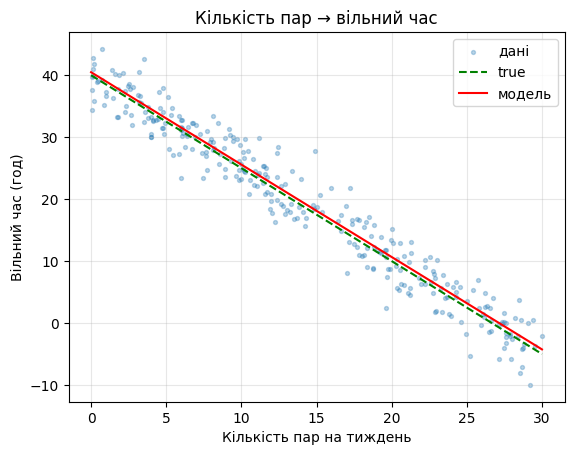

In [112]:
with torch.no_grad():
    x_line2 = torch.linspace(0, 30, 100).unsqueeze(1)
    y_line_true2 = TASK2_TRUE_W * x_line2 + TASK2_TRUE_B
    y_line_pred2 = task2_model(x_line2)

plt.scatter(x2.numpy(), y2.numpy(), s=8, alpha=0.3, label="дані")
plt.plot(x_line2.numpy(), y_line_true2.numpy(), "g--", label="true")
plt.plot(x_line2.numpy(), y_line_pred2.numpy(), "r-", label="модель")
plt.xlabel("Кількість пар на тиждень")
plt.ylabel("Вільний час (год)")
plt.title("Кількість пар → вільний час")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [113]:
model_path = os.path.join(ARTIFACT_DIR, "model.pt")
torch.save(task2_model.state_dict(), model_path)
print("Модель збережено в:", model_path)

Модель збережено в: /content/drive/MyDrive/ai_systems/lab1/model.pt


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [114]:
!pip install -q gradio

In [115]:
import gradio as gr

In [116]:
loaded_model = torch.nn.Linear(in_features=1, out_features=1)
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()

def predict_free_time(pairs_per_week):
    x_input = torch.tensor([[float(pairs_per_week)]])
    with torch.no_grad():
        prediction = loaded_model(x_input)
    return f"Прогнозований вільний час: {prediction.item():.2f} год/тиждень"

demo = gr.Interface(
    fn=predict_free_time,
    inputs=gr.Slider(minimum=0, maximum=30, step=1, value=10, label="Кількість пар на тиждень"),
    outputs=gr.Textbox(label="Прогноз"),
    title="Прогноз вільного часу студента",
    description="Модель лінійної регресії передбачає кількість вільних годин на тиждень залежно від кількості пар."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b711feae6151b2a670.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```